# Predicting Football Match Results from In-game Events

This notebook implements **Project 5: Predicting Football Games Result using In-game Events**.

The workflow is intentionally split into connected chunks:

1. Project setup and configuration
2. Match metadata loading
3. Event cleaning and feature engineering
4. Exploratory data analysis
5. Model training and comparison
6. Model evaluation and feature importance
7. Report-ready conclusions

The heavy reusable functions live in `football_result_prediction.py`, while this notebook shows the experiment flow clearly.

## 1. Setup

We import the reusable pipeline module and configure display options. The module also handles the local `scikit-learn` issue gracefully: if `scikit-learn` cannot import, it falls back to a NumPy multiclass logistic-regression implementation.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import football_result_prediction as frp

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
pd.set_option("display.width", 140)

print("scikit-learn available:", frp.SKLEARN_AVAILABLE)
if not frp.SKLEARN_AVAILABLE:
    print("scikit-learn import error:", frp.SKLEARN_IMPORT_ERROR)

scikit-learn available: False
scikit-learn import error: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


## 2. Configuration

`CUTOFF_MINUTE` controls how much of each match the model is allowed to see. For example, `45` means half-time prediction, while `75` means predicting late in the match before full time.

Team IDs are excluded by default so the model focuses on **in-game event behavior** rather than memorizing team strength.

In [2]:
DATA_DIR = Path("Data set")
OUTPUT_DIR = Path("artifacts_notebook")

CUTOFF_MINUTE = 75.0
TEST_SIZE = 0.20
SPLIT = "chronological"  # realistic future-match style evaluation
COMPETITIONS = None      # None uses every available competition
INCLUDE_TEAM_IDS = False # keep the project focused on in-game events

CV_FOLDS = 5 if frp.SKLEARN_AVAILABLE else 0
PERMUTATION_REPEATS = 8 if frp.SKLEARN_AVAILABLE else 0

output_paths = frp.ensure_output_dirs(OUTPUT_DIR)
competitions_filter = set(COMPETITIONS) if COMPETITIONS else None

print("Output folder:", OUTPUT_DIR.resolve())
print("Cutoff minute:", CUTOFF_MINUTE)
print("CV folds:", CV_FOLDS)
print("Permutation repeats:", PERMUTATION_REPEATS)

Output folder: /Users/abdelrahmannawara/Desktop/Me/AUC/Spring 2026/Machine Learning/Project/artifacts_notebook
Cutoff minute: 75.0
CV folds: 0
Permutation repeats: 0


## 3. Load Match Metadata

The match files provide the final target label: `home_win`, `draw`, or `away_win`. Final scores are used only to create the label and are excluded from model features.

In [3]:
team_names = frp.load_team_names(DATA_DIR)
matches_df = frp.parse_match_rows(DATA_DIR, competitions_filter, team_names)

print(f"Loaded {len(matches_df):,} played matches from {matches_df['competition'].nunique()} competitions.")
display(matches_df[[
    "match_id", "dateutc", "competition", "home_team_name", "away_team_name",
    "home_score", "away_score", "target"
]].head(10))

Loaded 1,941 played matches from 7 competitions.


,match_id,dateutc,competition,home_team_name,away_team_name,home_score,away_score,target
0,1694390,2016-06-10 19:00:00+00:00,European_Championship,France,Romania,2,1,home_win
1,1694391,2016-06-11 13:00:00+00:00,European_Championship,Albania,Switzerland,0,1,away_win
2,1694396,2016-06-11 16:00:00+00:00,European_Championship,Wales,Slovakia,2,1,home_win
3,1694397,2016-06-11 19:00:00+00:00,European_Championship,England,Russia,1,1,draw
4,1694408,2016-06-12 13:00:00+00:00,European_Championship,Turkey,Croatia,0,1,away_win
5,1694402,2016-06-12 16:00:00+00:00,European_Championship,Poland,Northern Ireland,1,0,home_win
6,1694403,2016-06-12 19:00:00+00:00,European_Championship,Germany,Ukraine,2,0,home_win
7,1694409,2016-06-13 13:00:00+00:00,European_Championship,Spain,Czech Republic,1,0,home_win
8,1694414,2016-06-13 16:00:00+00:00,European_Championship,Republic of Ireland,Sweden,1,1,draw
9,1694415,2016-06-13 19:00:00+00:00,European_Championship,Belgium,Italy,0,2,away_win


In [4]:
target_counts = matches_df["target"].value_counts().rename_axis("target").reset_index(name="matches")
competition_counts = matches_df["competition"].value_counts().rename_axis("competition").reset_index(name="matches")

display(target_counts)
display(competition_counts)

,target,matches
0,home_win,872
1,away_win,592
2,draw,477


,competition,matches
0,France,380
1,England,380
2,Spain,380
3,Italy,380
4,Germany,306
5,World_Cup,64
6,European_Championship,51


## 4. Clean Events and Engineer Features

For every match, event features are aggregated separately for the home and away teams up to `CUTOFF_MINUTE`.

Cleaning decisions include:

- removing duplicate event IDs
- keeping only events from known played matches
- keeping only events from the two teams in the match
- validating match periods and event times
- filtering events after the selected cutoff minute
- safely handling missing or invalid pitch coordinates

The engineered variables include score at cutoff, shots, shot-quality proxy, passes, pass accuracy, progressive passes, box entries, final-third actions, duels, cards, fouls, counter attacks, and event-share differences.

In [5]:
team_stats, cleaning = frp.load_event_features(
    data_dir=DATA_DIR,
    matches_df=matches_df,
    competitions=competitions_filter,
    cutoff_minute=CUTOFF_MINUTE,
)

feature_df = frp.build_feature_matrix(matches_df, team_stats, CUTOFF_MINUTE)
feature_cols, numeric_cols, categorical_cols = frp.modeling_columns(
    feature_df,
    include_team_ids=INCLUDE_TEAM_IDS,
)

feature_path = output_paths["tables"] / "engineered_match_features.csv"
feature_df.to_csv(feature_path, index=False)

print("Feature matrix shape:", feature_df.shape)
print("Number of model features:", len(feature_cols))
print("Numeric features:", len(numeric_cols))
print("Categorical features:", categorical_cols)
display(feature_df.head())

Loading events from England...


Loading events from European_Championship...


Loading events from France...


Loading events from Germany...


Loading events from Italy...


Loading events from Spain...


Loading events from World_Cup...


Feature matrix shape: (1941, 438)
Number of model features: 426
Numeric features: 425
Categorical features: ['competition']


,match_id,dateutc,competition,season_id,round_id,gameweek,duration,home_team_id,away_team_id,home_team_name,away_team_name,home_score,away_score,goal_diff_final,total_goals,target,cutoff_minute,home_current_goals,away_current_goals,current_goal_diff,abs_current_goal_diff,is_draw_at_cutoff,home_leading_at_cutoff,away_leading_at_cutoff,home_event_share,away_event_share,home_pass_share,away_pass_share,event_share_diff,pass_share_diff,home_accelerations,away_accelerations,diff_accelerations,home_accurate_crosses,away_accurate_crosses,diff_accurate_crosses,home_accurate_passes,away_accurate_passes,diff_accurate_passes,home_blocked_shots,...,diff_tag_opportunity,home_tag_own_goal,away_tag_own_goal,diff_tag_own_goal,home_tag_red_card,away_tag_red_card,diff_tag_red_card,home_tag_right_foot,away_tag_right_foot,diff_tag_right_foot,home_tag_second_yellow_card,away_tag_second_yellow_card,diff_tag_second_yellow_card,home_tag_sliding_tackle,away_tag_sliding_tackle,diff_tag_sliding_tackle,home_tag_through,away_tag_through,diff_tag_through,home_tag_yellow_card,away_tag_yellow_card,diff_tag_yellow_card,home_through_passes,away_through_passes,diff_through_passes,home_throw_ins,away_throw_ins,diff_throw_ins,home_touches,away_touches,diff_touches,home_xg_per_shot,away_xg_per_shot,diff_xg_per_shot,home_xg_proxy,away_xg_proxy,diff_xg_proxy,home_yellow_cards_total,away_yellow_cards_total,diff_yellow_cards_total
0,1694390,2016-06-10 19:00:00+00:00,European_Championship,9291,4165470,1,Regular,4418,11944,France,Romania,2,1,1,3,home_win,75.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.565317,0.434683,0.645609,0.354391,0.130634,0.291217,2.0,5.0,-3.0,7.0,2.0,5.0,354.0,173.0,181.0,3.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,14.0,-4.0,0.0,0.0,0.0,9.0,10.0,-1.0,10.0,1.0,9.0,1.0,2.0,-1.0,10.0,1.0,9.0,25.0,28.0,-3.0,37.0,33.0,4.0,0.478647,0.330405,0.148242,5.265120,2.312836,2.952284,1.0,2.0,-1.0
1,1694391,2016-06-11 13:00:00+00:00,European_Championship,9291,4165470,1,Regular,8731,6697,Albania,Switzerland,0,1,-1,1,away_win,75.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.439935,0.560065,0.414570,0.585430,-0.120130,-0.170861,3.0,5.0,-2.0,1.0,1.0,0.0,266.0,390.0,-124.0,2.0,...,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,8.0,0.0,1.0,0.0,1.0,4.0,6.0,-2.0,10.0,14.0,-4.0,2.0,2.0,0.0,10.0,14.0,-4.0,9.0,10.0,-1.0,23.0,20.0,3.0,0.445502,0.462228,-0.016726,1.782008,5.084504,-3.302496,2.0,2.0,0.0
2,1694396,2016-06-11 16:00:00+00:00,European_Championship,9291,4165470,1,Regular,10682,14496,Wales,Slovakia,2,1,1,3,home_win,75.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.458009,0.541991,0.439416,0.560584,-0.083981,-0.121168,4.0,9.0,-5.0,3.0,1.0,2.0,246.0,336.0,-90.0,0.0,...,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,7.0,1.0,0.0,0.0,0.0,6.0,4.0,2.0,0.0,4.0,-4.0,0.0,1.0,-1.0,0.0,4.0,-4.0,14.0,17.0,-3.0,25.0,27.0,-2.0,0.386218,0.402289,-0.016071,1.931092,3.620604,-1.689513,0.0,1.0,-1.0
3,1694397,2016-06-11 19:00:00+00:00,European_Championship,9291,4165470,1,Regular,2413,14358,England,Russia,1,1,0,2,draw,75.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.501608,0.498392,0.522137,0.477863,0.003215,0.044275,13.0,1.0,12.0,3.0,2.0,1.0,285.0,254.0,31.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,7.0,6.0,0.0,0.0,0.0,7.0,8.0,-1.0,12.0,3.0,9.0,1.0,1.0,0.0,12.0,3.0,9.0,20.0,20.0,0.0,19.0,25.0,-6.0,0.433780,0.343297,0.090483,3.904020,1.716487,2.187533,1.0,1.0,0.0
4,1694408,2016-06-12 13:00:00+00:00,European_Championship,9291,4165470,1,Regular,4687,9598,Turkey,Croatia,0,1,-1,1,away_win,75.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.524871,0.475129,0.487479,0.512521,0.049743,-0.025042,5.0,6.0,-1.0,2.0,12.0,-10.0,252.0,248.0,4.0,2.0,...,-9.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,25.0,-18.0,0.0,0.0,0.0,6.0,5.0,1.0,8.0,2.0,6.0,2.0,0.0,2.0,8.0,2.0,6.0,17.0,12.0,5.0,29.0,13.0,16.0,0.314140,0.441818,-0.127678,1.884839,5.743630,-3.858791,2.0,0.0,2.0


In [6]:
cleaning_summary = cleaning.to_jsonable()
cleaning_counts = {
    key: value
    for key, value in cleaning_summary.items()
    if not key.startswith("top_")
}

display(pd.DataFrame(cleaning_counts.items(), columns=["cleaning_metric", "count"]))
display(pd.DataFrame(cleaning_summary["top_event_names"], columns=["event", "count"]).head(10))
display(pd.DataFrame(cleaning_summary["top_subevent_names"], columns=["subevent", "count"]).head(15))

,cleaning_metric,count
0,raw_events,3251294
1,duplicate_events,0
2,events_after_cutoff,608408
3,events_for_unknown_match,0
4,events_for_unknown_team,0
5,events_without_valid_time,0
6,events_with_missing_coordinates,422
7,kept_events,2642886


,event,count
0,Pass,1374397
1,Duel,701785
2,Others on the ball,208026
3,Free Kick,154487
4,Interruption,105482
5,Foul,39783
6,Shot,33883
7,Save attempt,13706
8,Offside,6582
9,Goalkeeper leaving line,4755


,subevent,count
0,Simple pass,1067075
1,Ground attacking duel,224111
2,Ground defending duel,223119
3,Touch,142559
4,Air duel,132175
5,Ground loose ball duel,122380
6,High pass,107081
7,Ball out of the field,104744
8,Head pass,78166
9,Throw in,69227


## 5. Exploratory Data Analysis

This section saves report-ready tables and figures. The most useful EDA views are the class distribution, competition-level result mix, event frequencies, and feature relationships.

In [7]:
frp.make_eda_artifacts(
    feature_df=feature_df,
    feature_cols=feature_cols,
    cleaning=cleaning,
    output_paths=output_paths,
    cutoff_minute=CUTOFF_MINUTE,
)

eda_target = pd.read_csv(output_paths["tables"] / "eda_target_distribution.csv")
eda_competition = pd.read_csv(output_paths["tables"] / "eda_competition_summary.csv")
eda_signal = pd.read_csv(output_paths["tables"] / "eda_high_signal_feature_means.csv")

display(eda_target)
display(eda_competition)
display(eda_signal)

,target,matches
0,home_win,872
1,away_win,592
2,draw,477


,competition,matches,avg_total_goals
0,England,380,2.678947
1,France,380,2.718421
2,Italy,380,2.676316
3,Spain,380,2.694737
4,Germany,306,2.794118
5,World_Cup,64,2.593750
6,European_Championship,51,2.078431


,target,current_goal_diff,home_event_share,diff_xg_proxy,diff_shots,diff_shots_on_target_or_post,diff_pass_accuracy,diff_final_third_entries,diff_box_entries,diff_duel_win_rate,diff_red_cards_total
0,away_win,0.001689,0.488878,-1.048942,-0.834459,-1.408784,-0.017772,-39.677365,1.469595,-0.005710,0.040541
1,draw,0.004193,0.501371,0.539093,1.463312,0.285115,0.005485,-30.591195,6.387841,0.012911,0.010482
2,home_win,-0.001147,0.516399,2.377939,4.170872,2.354358,0.022678,-9.410550,12.959862,0.031709,-0.047018


### Target Distribution

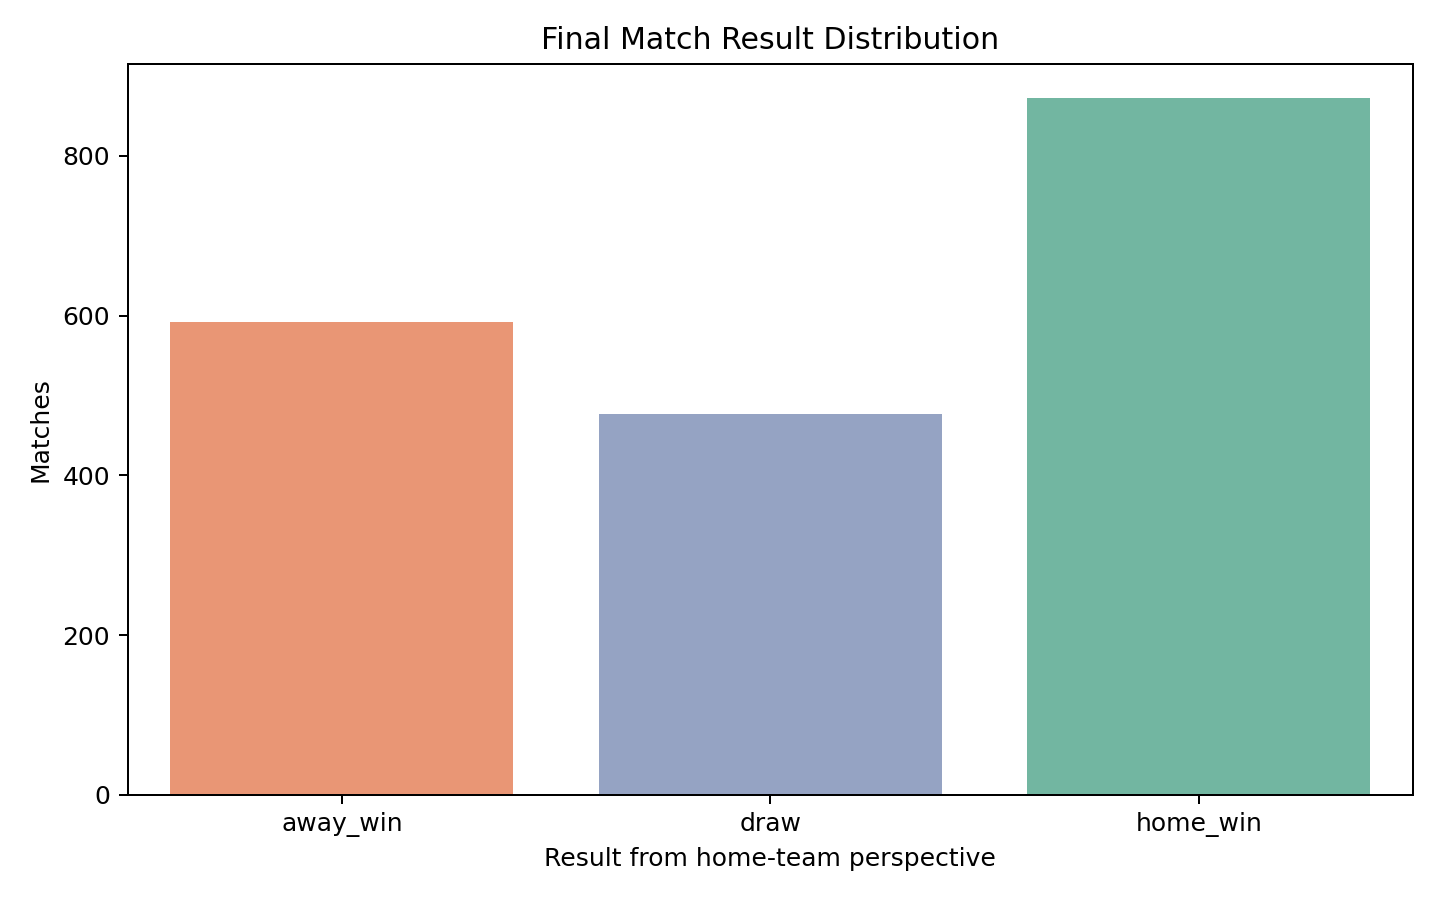

### Result Mix By Competition

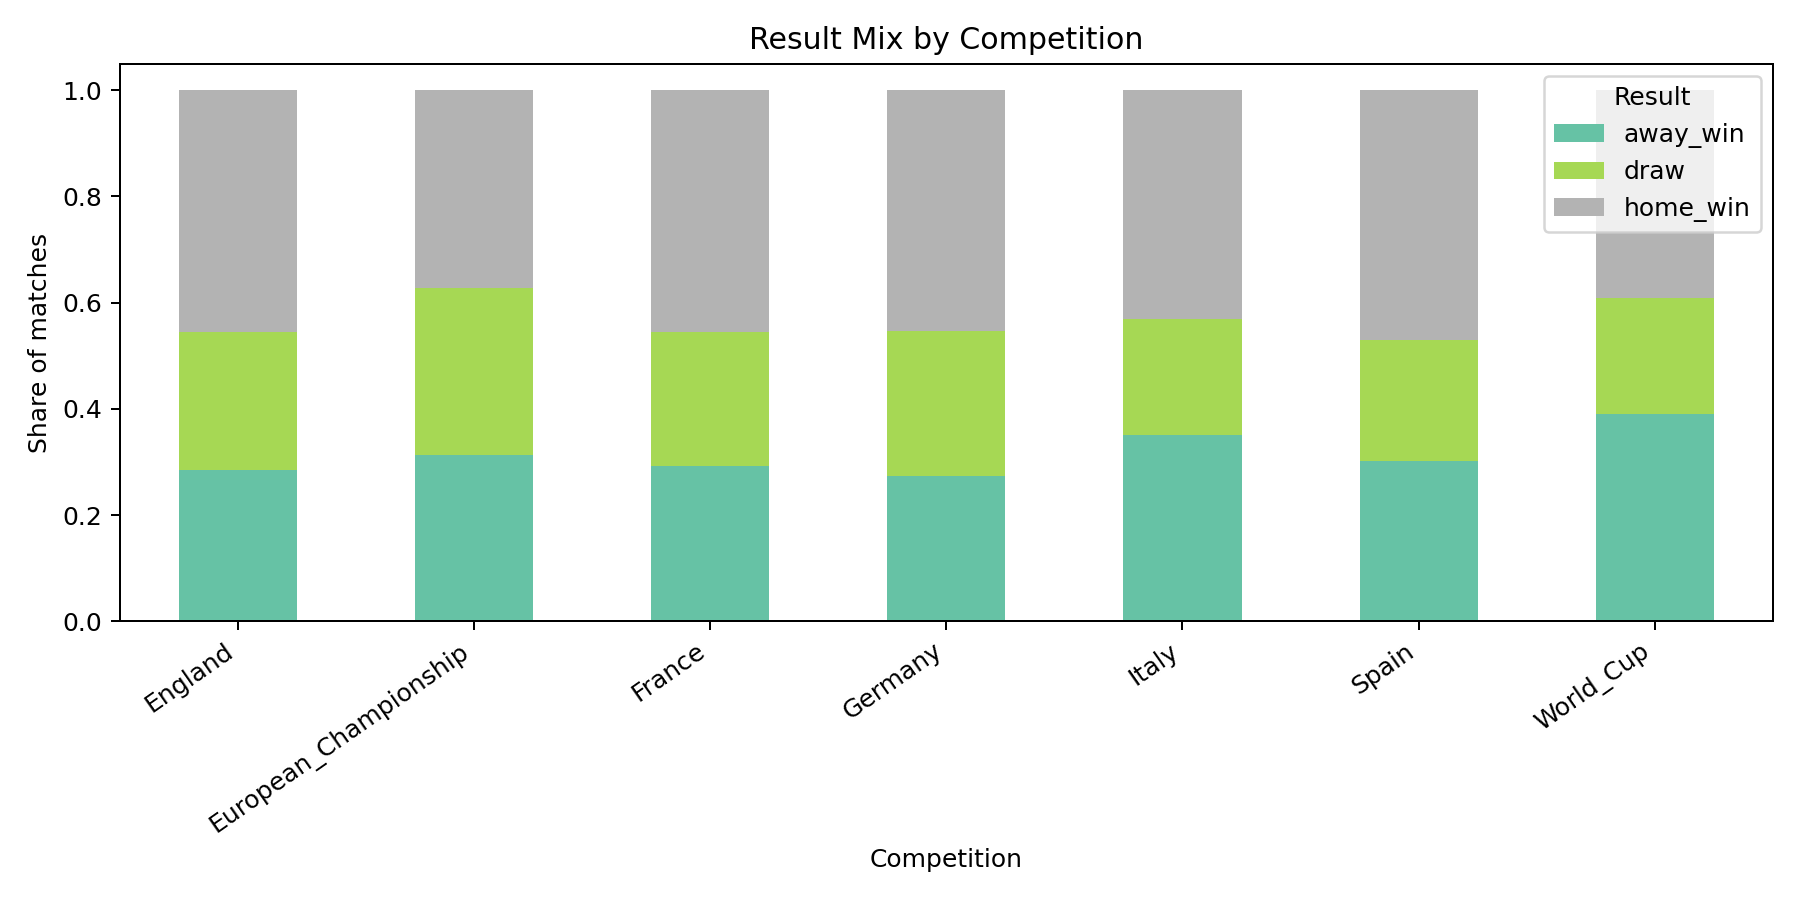

### Event Type Counts

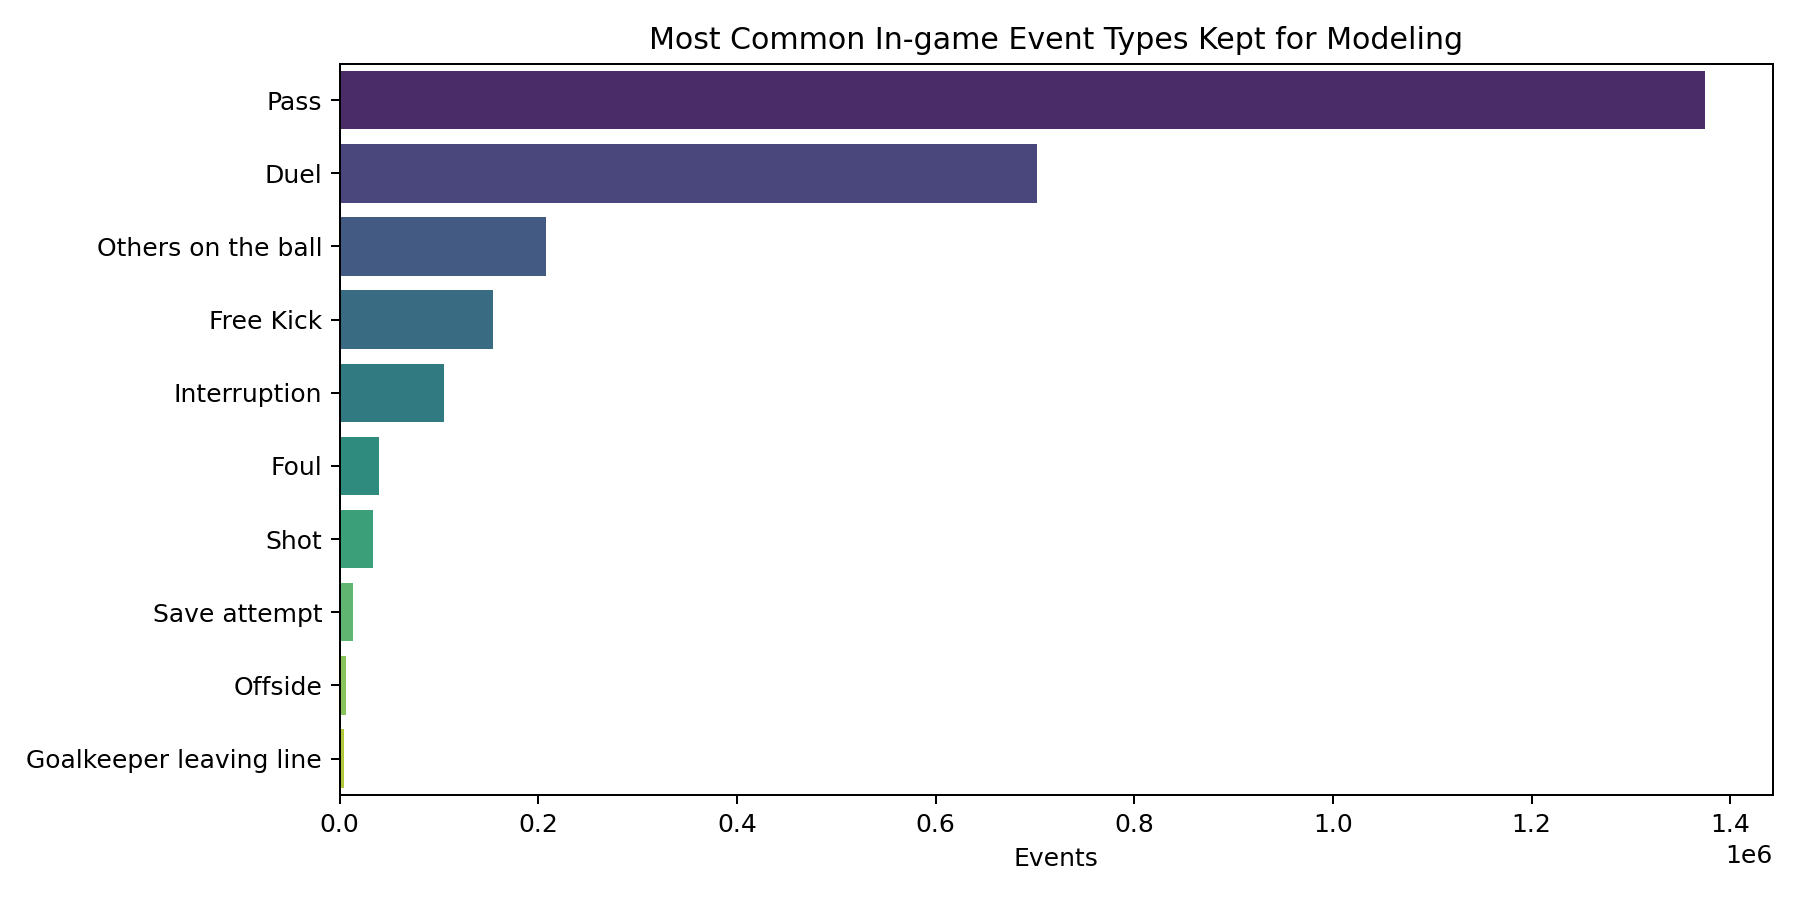

### Top Feature Correlation Heatmap

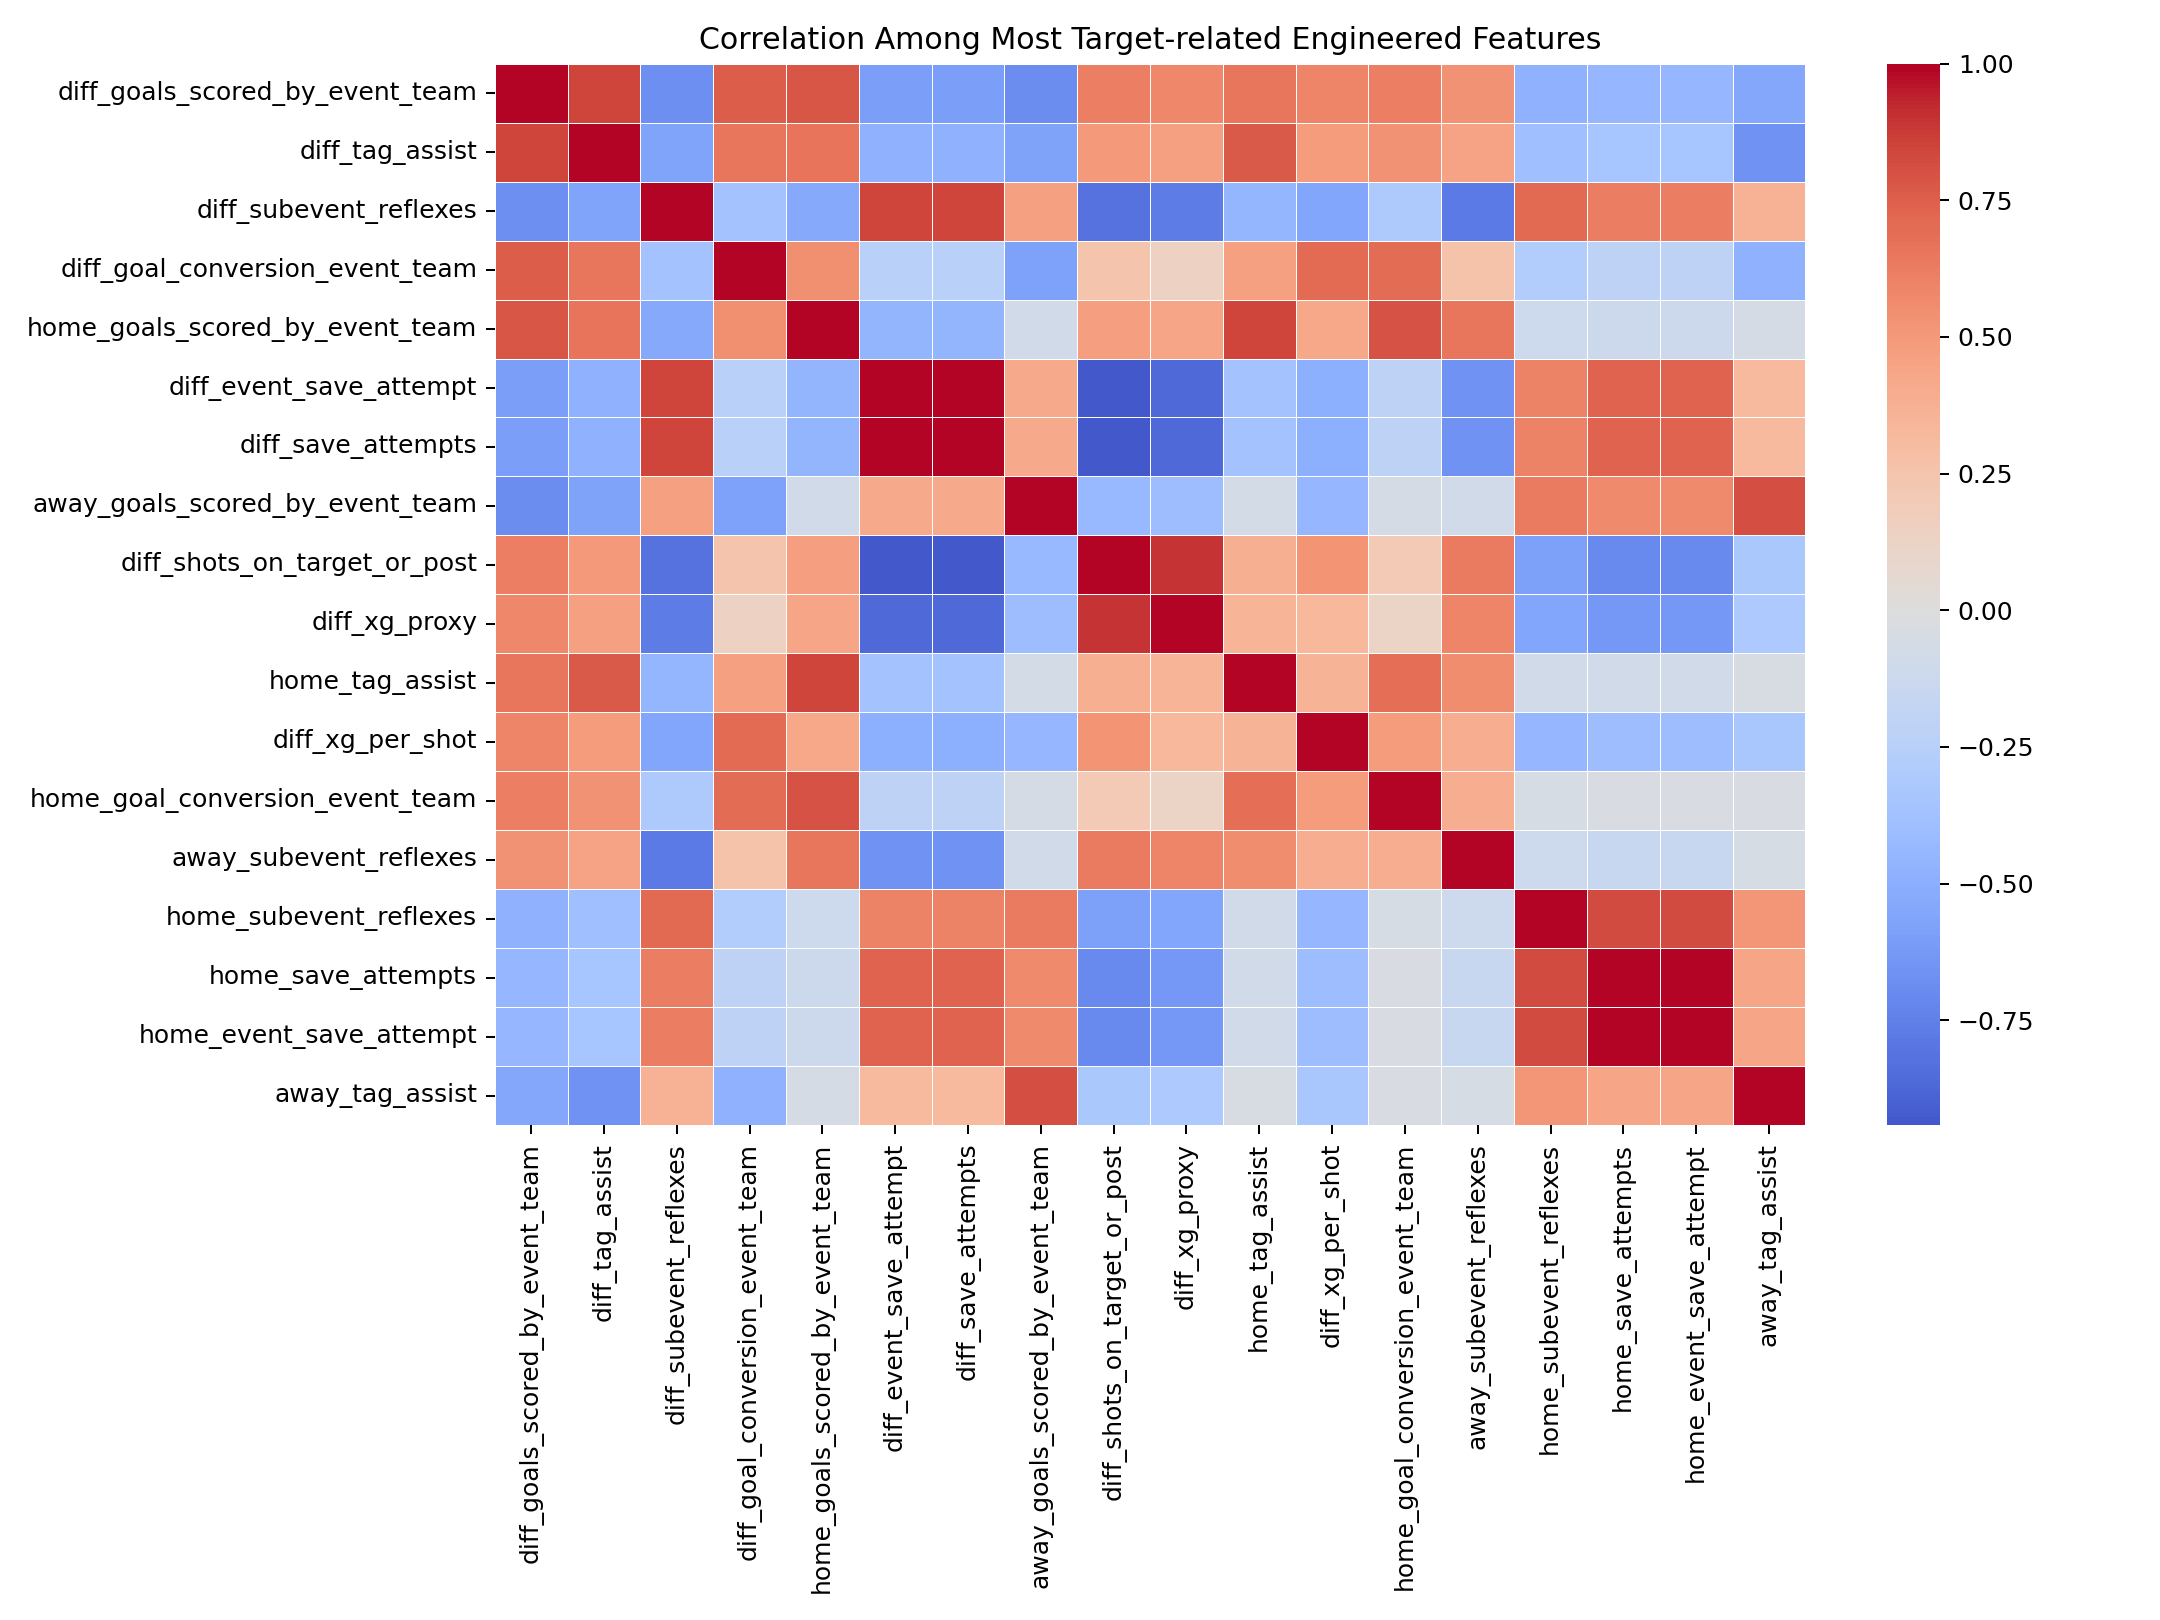

In [8]:
for image_name in [
    "target_distribution.png",
    "result_mix_by_competition.png",
    "event_type_counts.png",
    "top_feature_correlation_heatmap.png",
]:
    image_path = output_paths["figures"] / image_name
    display(Markdown(f"### {image_name.replace('_', ' ').replace('.png', '').title()}"))
    display(Image(filename=str(image_path)))

## 6. Train and Compare Models

The notebook compares a dummy baseline against stronger classifiers. When `scikit-learn` works, the pipeline includes logistic regression, random forest, extra trees, and histogram gradient boosting. In the current local environment, the notebook uses the built-in NumPy fallback because `scikit-learn` has a NumPy binary mismatch.

In [9]:
best_name, best_model, comparison_df = frp.train_and_evaluate_models(
    feature_df=feature_df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    output_paths=output_paths,
    test_size=TEST_SIZE,
    split=SPLIT,
    cv_folds=CV_FOLDS,
    permutation_repeats=PERMUTATION_REPEATS,
)

print("Best model:", best_name)
display(comparison_df)

scikit-learn is unavailable, using NumPy fallback models. Import error: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject
Training dummy_most_frequent_numpy...
Training softmax_logistic_regression_numpy...


Training softmax_logistic_regression_low_l2_numpy...


Best model: softmax_logistic_regression_low_l2_numpy


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
2,softmax_logistic_regression_low_l2_numpy,0.693299,0.666450,0.665608,0.706257
1,softmax_logistic_regression_numpy,0.688144,0.661810,0.660992,0.701251
0,dummy_most_frequent_numpy,0.461340,0.333333,0.210464,0.291287


## 7. Evaluate the Best Model

We inspect class-level performance and the confusion matrix. Draws are usually the hardest class because they are less frequent and can look statistically similar to narrow wins.

,precision,recall,f1-score,support
away_win,0.740741,0.666667,0.701754,120.0
draw,0.404959,0.550562,0.466667,89.0
home_win,0.880503,0.782123,0.828402,179.0
accuracy,0.693299,0.693299,0.693299,388.0
macro avg,0.675401,0.666450,0.665608,388.0
weighted avg,0.728197,0.693299,0.706257,388.0


,away_win,draw,home_win
away_win,80,37,3
draw,24,49,16
home_win,4,35,140


### Confusion Matrix

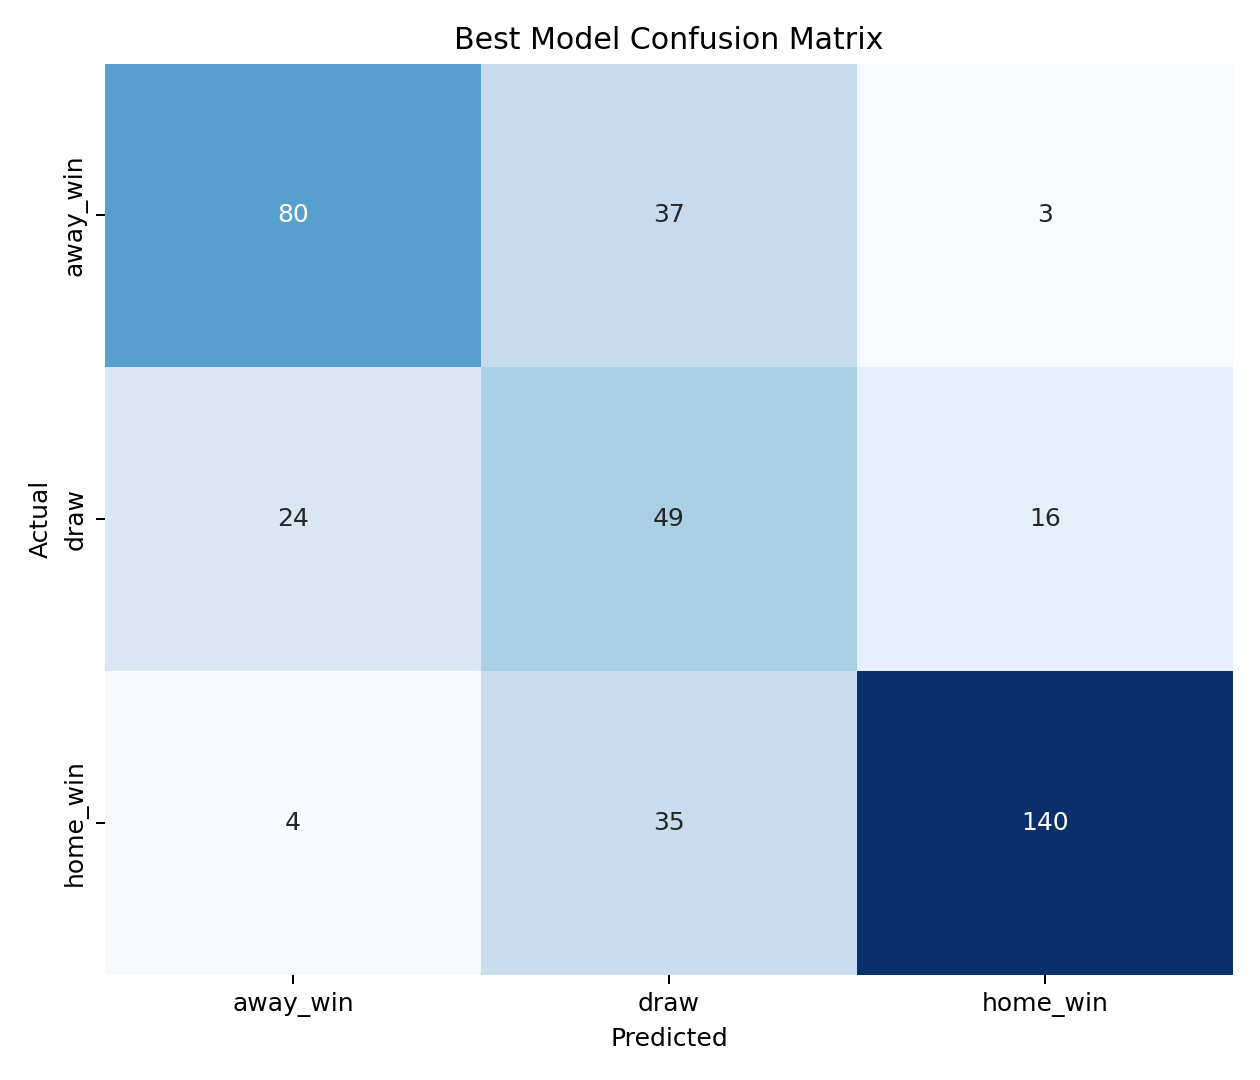

{'split': 'chronological',
 'test_size': 0.2,
 'train_matches': 1553,
 'test_matches': 388,
 'train_target_distribution': {'home_win': 693, 'away_win': 472, 'draw': 388},
 'test_target_distribution': {'home_win': 179, 'away_win': 120, 'draw': 89},
 'best_model': 'softmax_logistic_regression_low_l2_numpy',
 'best_model_metrics': {'model': 'softmax_logistic_regression_low_l2_numpy',
  'accuracy': 0.6932989690721649,
  'balanced_accuracy': 0.6664504564824695,
  'macro_f1': 0.6656078064984947,
  'weighted_f1': 0.706257431231345},
 'sklearn_available': False,
 'sklearn_import_error': 'numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject',
 'fallback_note': 'NumPy softmax regression was used because scikit-learn could not be imported.'}

In [10]:
classification_report_df = pd.read_csv(output_paths["tables"] / "classification_report_best_model.csv", index_col=0)
confusion_df = pd.read_csv(output_paths["tables"] / "confusion_matrix_best_model.csv", index_col=0)
modeling_summary = json.load(open(output_paths["tables"] / "modeling_summary.json"))

display(classification_report_df)
display(confusion_df)
display(Markdown("### Confusion Matrix"))
display(Image(filename=str(output_paths["figures"] / "best_model_confusion_matrix.png")))

modeling_summary

## 8. Most Effective Variables

Feature importance helps identify which in-game signals contributed most to prediction accuracy. In the fallback model, importance is based on logistic coefficient magnitude; when `scikit-learn` is available, the script uses permutation importance.

,feature,importance_mean,importance_std,importance_type
0,diff_goals_scored_by_event_team,0.524729,0.0,coefficient_magnitude
1,away_goals_scored_by_event_team,0.432984,0.0,coefficient_magnitude
2,home_goals_scored_by_event_team,0.361784,0.0,coefficient_magnitude
3,home_goal_conversion_event_team,0.228336,0.0,coefficient_magnitude
4,diff_goal_conversion_event_team,0.201700,0.0,coefficient_magnitude
5,away_goal_conversion_event_team,0.126963,0.0,coefficient_magnitude
6,away_duel_win_rate,0.120022,0.0,coefficient_magnitude
7,away_subevent_goal_kick,0.108130,0.0,coefficient_magnitude
8,home_mean_progression,0.103391,0.0,coefficient_magnitude
9,diff_tag_assist,0.102572,0.0,coefficient_magnitude


### Feature Importance

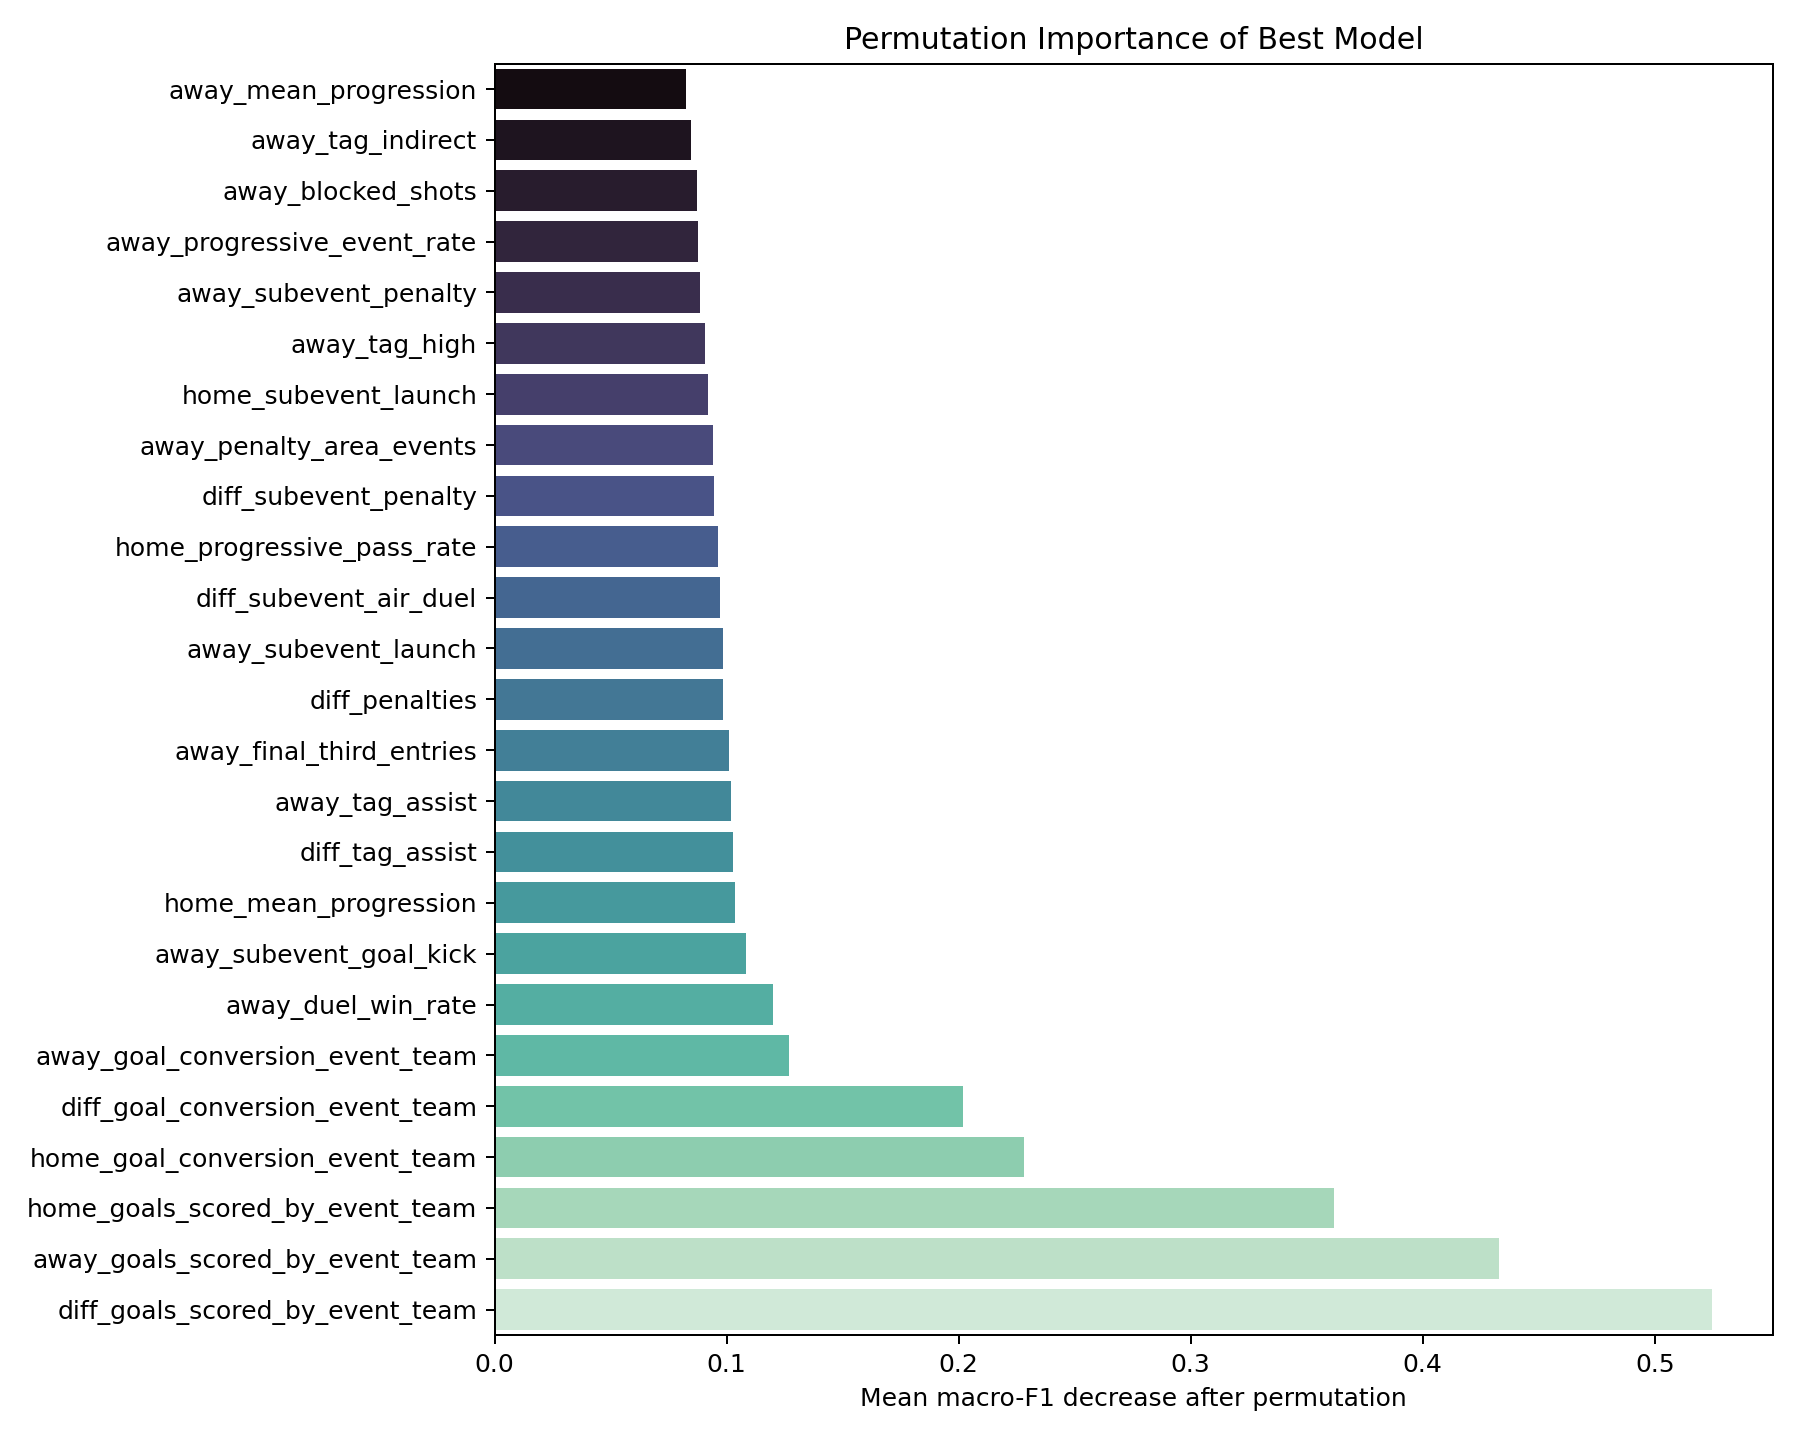

In [11]:
importance_df = pd.read_csv(output_paths["tables"] / "permutation_importance.csv")

display(importance_df.head(25))
display(Markdown("### Feature Importance"))
display(Image(filename=str(output_paths["figures"] / "permutation_feature_importance.png")))

## 9. Report-ready Interpretation

Use this cell to produce a concise numerical summary for the report and presentation.

In [12]:
eda_summary = json.load(open(output_paths["tables"] / "eda_summary.json"))
best_metrics = comparison_df.iloc[0]
baseline = comparison_df[comparison_df["model"].str.contains("dummy", case=False)].iloc[0]
top_features = importance_df.head(10)["feature"].tolist()

summary_markdown = f"""
### Key Results

- Matches analyzed: **{eda_summary['matches']:,}** across **{len(eda_summary['competitions'])}** competitions.
- Events processed before cleaning: **{eda_summary['cleaning_report']['raw_events']:,}**.
- Events retained up to minute {CUTOFF_MINUTE:g}: **{eda_summary['cleaning_report']['kept_events']:,}**.
- Engineered model features: **{eda_summary['features']:,}**.
- Best model: **{best_metrics['model']}**.
- Best model accuracy: **{best_metrics['accuracy']:.3f}**.
- Best model macro-F1: **{best_metrics['macro_f1']:.3f}**.
- Dummy baseline accuracy: **{baseline['accuracy']:.3f}**.

### Strongest Signals

The most influential variables in this run were:

{chr(10).join(f'- `{feature}`' for feature in top_features)}

### Interpretation

The model is most helped by the current goal situation, goal/shot conversion indicators, attacking progression, final-third and box activity, assists/key attacking tags, duel outcomes, and set-piece pressure. These variables are football-plausible because they summarize whether a team is already ahead, creating high-value chances, sustaining pressure, and controlling dangerous areas before full time.
"""

display(Markdown(summary_markdown))


### Key Results

- Matches analyzed: **1,941** across **7** competitions.
- Events processed before cleaning: **3,251,294**.
- Events retained up to minute 75: **2,642,886**.
- Engineered model features: **426**.
- Best model: **softmax_logistic_regression_low_l2_numpy**.
- Best model accuracy: **0.693**.
- Best model macro-F1: **0.666**.
- Dummy baseline accuracy: **0.461**.

### Strongest Signals

The most influential variables in this run were:

- `diff_goals_scored_by_event_team`
- `away_goals_scored_by_event_team`
- `home_goals_scored_by_event_team`
- `home_goal_conversion_event_team`
- `diff_goal_conversion_event_team`
- `away_goal_conversion_event_team`
- `away_duel_win_rate`
- `away_subevent_goal_kick`
- `home_mean_progression`
- `diff_tag_assist`

### Interpretation

The model is most helped by the current goal situation, goal/shot conversion indicators, attacking progression, final-third and box activity, assists/key attacking tags, duel outcomes, and set-piece pressure. These variables are football-plausible because they summarize whether a team is already ahead, creating high-value chances, sustaining pressure, and controlling dangerous areas before full time.


## 10. Optional Experiments

To compare prediction timing, rerun the notebook with different `CUTOFF_MINUTE` values such as `45`, `60`, `75`, and `90`. Earlier cutoffs are harder but more useful for live tactical decisions.

In [13]:
# Example experiment idea:
# for minute in [45, 60, 75, 90]:
#     set CUTOFF_MINUTE = minute in the configuration cell
#     rerun the notebook
#     compare model_comparison.csv across output folders

print("Notebook complete. Main artifacts are in:", OUTPUT_DIR.resolve())

Notebook complete. Main artifacts are in: /Users/abdelrahmannawara/Desktop/Me/AUC/Spring 2026/Machine Learning/Project/artifacts_notebook
